# 02 — Data Quality Deep Dive
## easyMoney | TFM Data Science & AI — Nuclio School

---

## Objetivo
Revisión exhaustiva columna por columna de la tabla maestra para detectar
anomalías, inconsistencias y problemas de calidad que podrían afectar
los análisis posteriores (segmentación, recomendación, personalización).

---


In [1]:
# ── 02 — Data Quality Deep Dive ────────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = 'C:\\Users\\farno\\OneDrive\\Desktop\\Data science & AI - Nuclio School\\proyecto final TFM\\tfm-fintech-easymoney\\data\\processed\\master_df.parquet'

df = pd.read_parquet(DATA_PATH)

print(f"✓ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<15} {df[col].nunique():>8} únicos")

✓ Datos cargados: 5,962,924 filas × 34 columnas

Columnas disponibles:
  pk_cid                    int64             456373 únicos
  pk_partition              datetime64[ns]        17 únicos
  entry_date                datetime64[ns]      1497 únicos
  entry_channel             object                69 únicos
  active_customer           float64                2 únicos
  segment                   object                 3 únicos
  short_term_deposit        int64                  2 únicos
  loans                     int64                  2 únicos
  mortgage                  int64                  2 únicos
  funds                     int64                  2 únicos
  securities                int64                  2 únicos
  long_term_deposit         int64                  2 únicos
  credit_card               int64                  2 únicos
  payroll                   int64                  2 únicos
  pension_plan              int64                  2 únicos
  payroll_account           i

In [2]:
# ── Análisis de la columna age ─────────────────────────────────────────────

print("=" * 50)
print("  AGE — Análisis completo")
print("=" * 50)

print(f"\nEstadísticas generales:")
print(df['age'].describe())

print(f"\nDistribución por grupos de edad:")
print(f"  Edad < 18:     {(df['age'] < 18).sum():>10,} registros  ({(df['age'] < 18).mean()*100:.2f}%)")
print(f"  Edad 18-24:    {df['age'].between(18,24).sum():>10,} registros  ({df['age'].between(18,24).mean()*100:.2f}%)")
print(f"  Edad 25-64:    {df['age'].between(25,64).sum():>10,} registros  ({df['age'].between(25,64).mean()*100:.2f}%)")
print(f"  Edad 65+:      {(df['age'] >= 65).sum():>10,} registros  ({(df['age'] >= 65).mean()*100:.2f}%)")
print(f"  Edad < 5:      {(df['age'] < 5).sum():>10,} registros  ← sospechoso!")
print(f"  Edad > 100:    {(df['age'] > 100).sum():>10,} registros  ← sospechoso!")

print(f"\nEdades más bajas:")
print(df['age'].value_counts().sort_index().head(10))

print(f"\nEdades más altas:")
print(df['age'].value_counts().sort_index().tail(10))

print(f"\n¿Los menores de 18 tienen productos contratados?")
minor_products = df[df['age'] < 18]['total_products'].value_counts().sort_index()
print(minor_products)

  AGE — Análisis completo

Estadísticas generales:
count    5.962924e+06
mean     2.976042e+01
std      1.198038e+01
min      2.000000e+00
25%      2.200000e+01
50%      2.500000e+01
75%      3.400000e+01
max      1.050000e+02
Name: age, dtype: float64

Distribución por grupos de edad:
  Edad < 18:         35,873 registros  (0.60%)
  Edad 18-24:     2,933,206 registros  (49.19%)
  Edad 25-64:     2,861,584 registros  (47.99%)
  Edad 65+:         132,261 registros  (2.22%)
  Edad < 5:           4,432 registros  ← sospechoso!
  Edad > 100:           201 registros  ← sospechoso!

Edades más bajas:
age
2      688
3     1534
4     2210
5     2920
6     3043
7     2191
8     2216
9     2470
10    2247
11    2254
Name: count, dtype: int64

Edades más altas:
age
96     346
97     300
98     184
99      94
100    112
101     91
102     65
103     25
104     12
105      8
Name: count, dtype: int64

¿Los menores de 18 tienen productos contratados?
total_products
0    35637
1      228
2        8
N

In [3]:
# ── Variables necesarias ───────────────────────────────────────────────────
product_cols = ['short_term_deposit','loans','mortgage','funds','securities',
                'long_term_deposit','credit_card','payroll','pension_plan',
                'payroll_account','emc_account','debit_card','em_account_p',
                'em_acount']

print(f"✓ product_cols definido: {len(product_cols)} productos")

✓ product_cols definido: 14 productos


In [4]:
# ── Análisis profundo de edades anómalas ───────────────────────────────────

print("=" * 50)
print("  MENORES DE 18 CON PRODUCTOS")
print("=" * 50)

menores_con_productos = df[(df['age'] < 18) & (df['total_products'] > 0)]
print(f"\nTotal registros: {len(menores_con_productos):,}")
print(f"\nDistribución por edad:")
print(menores_con_productos['age'].value_counts().sort_index())
print(f"\nProductos que tienen contratados:")
for col in product_cols:
    count = menores_con_productos[col].sum()
    if count > 0:
        print(f"  {col:<25} {count:>6,}")

print(f"\nSegmento al que pertenecen:")
print(menores_con_productos['segment'].value_counts())

print("\n" + "=" * 50)
print("  EDAD > 100 — ANÁLISIS")
print("=" * 50)
mayores_100 = df[df['age'] > 100]
print(f"\nTotal registros: {len(mayores_100):,}")
print(f"Clientes únicos: {mayores_100['pk_cid'].nunique():,}")
print(f"\nDistribución por edad:")
print(mayores_100['age'].value_counts().sort_index())
print(f"\nTienen productos:")
print(mayores_100['total_products'].value_counts().sort_index())
print(f"\nActive customer:")
print(mayores_100['active_customer'].value_counts())

print("\n" + "=" * 50)
print("  EDAD < 5 — SON ERRORES O DATOS REALES?")
print("=" * 50)
menores_5 = df[df['age'] < 5]
print(f"\nTotal registros: {len(menores_5):,}")
print(f"Clientes únicos: {menores_5['pk_cid'].nunique():,}")
print(f"\nTienen productos:")
print(menores_5['total_products'].value_counts().sort_index())
print(f"\nSalary de estos clientes:")
print(menores_5['salary'].describe())
print(f"\nSon clientes activos:")
print(menores_5['active_customer'].value_counts())

  MENORES DE 18 CON PRODUCTOS

Total registros: 236

Distribución por edad:
age
2      7
3      5
4     22
5     15
6     13
7      6
8     20
9     15
10    20
11     3
12    12
13    21
14    11
15    11
16    30
17    25
Name: count, dtype: int64

Productos que tienen contratados:
  payroll                        8
  pension_plan                 187
  em_acount                     49

Segmento al que pertenecen:
segment
02 - PARTICULARES     230
03 - UNIVERSITARIO      6
Name: count, dtype: int64

  EDAD > 100 — ANÁLISIS

Total registros: 201
Clientes únicos: 21

Distribución por edad:
age
101    91
102    65
103    25
104    12
105     8
Name: count, dtype: int64

Tienen productos:
total_products
0    79
1    88
2    12
3    17
4     4
5     1
Name: count, dtype: int64

Active customer:
active_customer
0.0    130
1.0     71
Name: count, dtype: int64

  EDAD < 5 — SON ERRORES O DATOS REALES?

Total registros: 4,432
Clientes únicos: 455

Tienen productos:
total_products
0    4398
1  

In [5]:
# ── Decisión sobre edades anómalas ─────────────────────────────────────────

print("=" * 50)
print("  IMPACTO REAL EN EL ANÁLISIS")
print("=" * 50)

total = len(df)
pct_menor5 = (df['age'] < 5).mean() * 100
pct_mayor100 = (df['age'] > 100).mean() * 100
pct_menor18_productos = len(df[(df['age'] < 18) & 
                               (df['total_products'] > 0)]) / total * 100

print(f"\nImpacto porcentual:")
print(f"  Edad < 5:              {pct_menor5:.4f}% del total")
print(f"  Edad > 100:            {pct_mayor100:.4f}% del total")
print(f"  <18 con productos:     {pct_menor18_productos:.4f}% del total")

print(f"\n¿Los menores de 5 tienen siempre salary imputado?")
menores5 = df[df['age'] < 5]
print(f"  salary_imputed=True:  {menores5['salary_imputed'].sum():,}")
print(f"  salary_imputed=False: {(~menores5['salary_imputed']).sum():,}")

print(f"\n¿Los >100 tienen siempre salary imputado?")
mayores100 = df[df['age'] > 100]
print(f"  salary_imputed=True:  {mayores100['salary_imputed'].sum():,}")
print(f"  salary_imputed=False: {(~mayores100['salary_imputed']).sum():,}")

print(f"\nPension_plan en menores de 18:")
print(df[df['age'] < 18].groupby('age')['pension_plan'].sum().to_string())

  IMPACTO REAL EN EL ANÁLISIS

Impacto porcentual:
  Edad < 5:              0.0743% del total
  Edad > 100:            0.0034% del total
  <18 con productos:     0.0040% del total

¿Los menores de 5 tienen siempre salary imputado?
  salary_imputed=True:  1,151
  salary_imputed=False: 3,281

¿Los >100 tienen siempre salary imputado?
  salary_imputed=True:  68
  salary_imputed=False: 133

Pension_plan en menores de 18:
age
2      0
3      3
4     11
5      9
6     13
7      6
8     20
9     14
10    11
11     3
12    12
13    21
14    11
15    11
16    30
17    12


In [6]:
# ── Flag de anomalías de edad ──────────────────────────────────────────────

# Definir criterios de anomalía
df['age_anomaly'] = False

# Criterio 1: edad < 5 (errores de registro)
mask_age_low = df['age'] < 5
df.loc[mask_age_low, 'age_anomaly'] = True

# Criterio 2: edad > 100 (sospechoso)
mask_age_high = df['age'] > 100
df.loc[mask_age_high, 'age_anomaly'] = True

# Criterio 3: menor de 18 con pension_plan (imposible legalmente)
mask_minor_pension = (df['age'] < 18) & (df['pension_plan'] == 1)
df.loc[mask_minor_pension, 'age_anomaly'] = True

# Resumen
print("=" * 50)
print("  RESUMEN FLAG age_anomaly")
print("=" * 50)
print(f"\nTotal registros marcados: {df['age_anomaly'].sum():,}")
print(f"Porcentaje del total:     {df['age_anomaly'].mean()*100:.4f}%")
print(f"Clientes únicos afectados: {df[df['age_anomaly']]['pk_cid'].nunique():,}")

print(f"\nDesglose por criterio:")
print(f"  Edad < 5:                    {mask_age_low.sum():>8,}")
print(f"  Edad > 100:                  {mask_age_high.sum():>8,}")
print(f"  Menor 18 con pension_plan:   {mask_minor_pension.sum():>8,}")

print(f"\nVerificación — age_anomaly en tabla maestra:")
print(df['age_anomaly'].value_counts())

  RESUMEN FLAG age_anomaly

Total registros marcados: 4,806
Porcentaje del total:     0.0806%
Clientes únicos afectados: 504

Desglose por criterio:
  Edad < 5:                       4,432
  Edad > 100:                       201
  Menor 18 con pension_plan:        187

Verificación — age_anomaly en tabla maestra:
age_anomaly
False    5958118
True        4806
Name: count, dtype: int64


In [7]:
# ── Análisis active_customer ───────────────────────────────────────────────
print("\n" + "=" * 50)
print("  ACTIVE_CUSTOMER — Análisis completo")
print("=" * 50)

print(f"\nTipo de dato: {df['active_customer'].dtype}")
print(f"Valores únicos: {df['active_customer'].unique()}")
print(f"Distribución:")
print(df['active_customer'].value_counts(dropna=False))
print(f"\nNulos: {df['active_customer'].isna().sum()}")

print(f"\n¿Clientes inactivos tienen productos?")
inactivos = df[df['active_customer'] == 0.0]
print(f"  Total inactivos: {len(inactivos):,}")
print(f"  Con 0 productos: {(inactivos['total_products'] == 0).sum():,} ({(inactivos['total_products'] == 0).mean()*100:.1f}%)")
print(f"  Con 1+ productos: {(inactivos['total_products'] >= 1).sum():,} ({(inactivos['total_products'] >= 1).mean()*100:.1f}%)")

print(f"\n¿Clientes activos sin productos?")
activos = df[df['active_customer'] == 1.0]
print(f"  Total activos: {len(activos):,}")
print(f"  Con 0 productos: {(activos['total_products'] == 0).sum():,} ({(activos['total_products'] == 0).mean()*100:.1f}%)")
print(f"  Con 1+ productos: {(activos['total_products'] >= 1).sum():,} ({(activos['total_products'] >= 1).mean()*100:.1f}%)")


  ACTIVE_CUSTOMER — Análisis completo

Tipo de dato: float64
Valores únicos: [1. 0.]
Distribución:
active_customer
0.0    3557573
1.0    2405351
Name: count, dtype: int64

Nulos: 0

¿Clientes inactivos tienen productos?
  Total inactivos: 3,557,573
  Con 0 productos: 1,059,439 (29.8%)
  Con 1+ productos: 2,498,134 (70.2%)

¿Clientes activos sin productos?
  Total activos: 2,405,351
  Con 0 productos: 62,068 (2.6%)
  Con 1+ productos: 2,343,283 (97.4%)


In [8]:
# ── Análisis entry_channel ─────────────────────────────────────────────────
print("=" * 50)
print("  ENTRY_CHANNEL — Análisis completo")
print("=" * 50)

print(f"\nTotal valores únicos: {df['entry_channel'].nunique()}")
print(f"Nulos: {df['entry_channel'].isna().sum()}")
print(f"UNKNOWN (imputados): {(df['entry_channel'] == 'UNKNOWN').sum():,}")

print(f"\nTop 20 canales más frecuentes:")
top_channels = df['entry_channel'].value_counts().head(20)
print(top_channels.to_string())

print(f"\nCanales con menos de 100 registros (posibles errores):")
rare_channels = df['entry_channel'].value_counts()
rare = rare_channels[rare_channels < 100]
print(f"  Total canales raros: {len(rare)}")
print(rare.to_string())

print(f"\n¿Los canales principales son consistentes?")
print(f"  Canales que acumulan el 80% del tráfico:")
cumsum = df['entry_channel'].value_counts(normalize=True).cumsum()
top_80 = cumsum[cumsum <= 0.80]
print(f"  {len(top_80)} canales = 80% del total")
print(top_80.to_string())

  ENTRY_CHANNEL — Análisis completo

Total valores únicos: 69
Nulos: 0
UNKNOWN (imputados): 132,423

Top 20 canales más frecuentes:
entry_channel
KHE        3114084
KFC         891093
KHQ         590280
KAT         416084
KHK         230197
KHM         176591
UNKNOWN     132423
KHN         108434
KFA          79020
KHD          75899
RED          60601
KHL          41736
KHF          20657
KHO           8247
KAZ           5635
KHC           5241
KBG           1662
KEH            728
KHP            691
007            613

Canales con menos de 100 registros (posibles errores):
  Total canales raros: 41
entry_channel
KAB    95
KFD    91
KCC    89
KAW    65
KAQ    52
KDH    51
KAE    48
KCH    48
KCB    47
KAD    45
KAM    43
KAH    40
KAK    34
KAJ    33
KDT    23
KFF    22
KBO    21
KEY    20
KBE    17
KCL    17
KGN    17
KBH    17
KGC    17
KGX    17
004    17
KFK    17
KFS    17
KCI    17
KDR    16
KFL    13
KBW    12
KBU    11
KCK    11
KBY    11
KAI    11
KES    11
KEJ     8
KHS     

In [9]:
# ── Análisis country_id ────────────────────────────────────────────────────
print("=" * 50)
print("  COUNTRY_ID — Análisis completo")
print("=" * 50)

print(f"\nTotal valores únicos: {df['country_id'].nunique()}")
print(f"\nDistribución completa:")
country_dist = df['country_id'].value_counts()
country_pct = df['country_id'].value_counts(normalize=True) * 100
country_summary = pd.DataFrame({
    'registros': country_dist,
    'pct': country_pct.round(2)
})
print(country_summary.to_string())

print(f"\n¿ES domina?")
es_pct = (df['country_id'] == 'ES').mean() * 100
print(f"  España (ES): {es_pct:.2f}% del total")
print(f"  Resto:       {100-es_pct:.2f}% del total")

print(f"\nClientes únicos por país (top 10):")
unique_by_country = df.groupby('country_id')['pk_cid'].nunique().sort_values(ascending=False).head(10)
print(unique_by_country.to_string())

  COUNTRY_ID — Análisis completo

Total valores únicos: 41

Distribución completa:
            registros    pct
country_id                  
ES            5960672  99.96
GB                441   0.01
FR                225   0.00
DE                199   0.00
US                195   0.00
CH                194   0.00
BR                 87   0.00
BE                 81   0.00
VE                 79   0.00
IE                 68   0.00
MX                 58   0.00
AT                 51   0.00
AR                 51   0.00
PL                 49   0.00
IT                 45   0.00
MA                 34   0.00
CL                 30   0.00
CN                 28   0.00
CA                 22   0.00
GA                 17   0.00
GT                 17   0.00
NO                 17   0.00
RU                 17   0.00
MR                 17   0.00
CO                 17   0.00
SN                 17   0.00
DO                 17   0.00
LU                 17   0.00
QA                 17   0.00
CI                

In [10]:
# ── Análisis deceased ──────────────────────────────────────────────────────
print("=" * 50)
print("  DECEASED — Análisis completo")
print("=" * 50)

print(f"\nValores únicos: {df['deceased'].unique()}")
print(f"\nDistribución:")
print(df['deceased'].value_counts(dropna=False))

print(f"\n¿Clientes fallecidos siguen activos?")
fallecidos = df[df['deceased'] == 'S']
print(f"  Total registros fallecidos: {len(fallecidos):,}")
print(f"  Clientes únicos fallecidos: {fallecidos['pk_cid'].nunique():,}")
print(f"  Active customer = 1: {(fallecidos['active_customer'] == 1.0).sum():,}")
print(f"  Active customer = 0: {(fallecidos['active_customer'] == 0.0).sum():,}")

print(f"\n¿Tienen productos contratados?")
print(fallecidos['total_products'].value_counts().sort_index())

print(f"\n¿Siguen contratando productos nuevos?")
print(f"  New contracts > 0: {(fallecidos['new_contracts'] > 0).sum():,}")

print(f"\nEvolución de fallecidos por período:")
print(df[df['deceased'] == 'S'].groupby('pk_partition')['pk_cid'].nunique().to_string())

  DECEASED — Análisis completo

Valores únicos: ['N' 'S']

Distribución:
deceased
N    5961849
S       1075
Name: count, dtype: int64

¿Clientes fallecidos siguen activos?
  Total registros fallecidos: 1,075
  Clientes únicos fallecidos: 129
  Active customer = 1: 718
  Active customer = 0: 357

¿Tienen productos contratados?
total_products
0    236
1    387
2    289
3    135
4     17
5     11
Name: count, dtype: int64

¿Siguen contratando productos nuevos?
  New contracts > 0: 51

Evolución de fallecidos por período:
pk_partition
2018-01-28    47
2018-02-28    47
2018-03-28    47
2018-04-28    46
2018-05-28    47
2018-06-28    45
2018-07-28    55
2018-08-28    57
2018-09-28    64
2018-10-28    68
2018-11-28    71
2018-12-28    74
2019-01-28    73
2019-02-28    80
2019-03-28    84
2019-04-28    84
2019-05-28    86


In [11]:
# ── Flag deceased anomalies ────────────────────────────────────────────────

# Flag: fallecido pero activo o con nuevas contrataciones
df['deceased_anomaly'] = (
    (df['deceased'] == 'S') & 
    ((df['active_customer'] == 1.0) | (df['new_contracts'] > 0))
)

print(f"✓ deceased_anomaly flagged: {df['deceased_anomaly'].sum():,} registros")
print(f"  Clientes únicos: {df[df['deceased_anomaly']]['pk_cid'].nunique():,}")

# ── Análisis segment ───────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("  SEGMENT — Análisis completo")
print("=" * 50)

print(f"\nValores únicos: {df['segment'].nunique()}")
print(f"\nDistribución:")
seg_dist = df['segment'].value_counts(dropna=False)
seg_pct = df['segment'].value_counts(normalize=True, dropna=False) * 100
print(pd.DataFrame({'registros': seg_dist, 'pct': seg_pct.round(2)}).to_string())

print(f"\n¿UNKNOWN tiene comportamiento diferente?")
for seg in df['segment'].unique():
    avg_prod = df[df['segment'] == seg]['total_products'].mean()
    active_pct = (df[df['segment'] == seg]['active_customer'] == 1.0).mean() * 100
    print(f"  {seg:<25} avg_products: {avg_prod:.2f}  active: {active_pct:.1f}%")

print(f"\nClientes únicos por segmento:")
print(df.groupby('segment')['pk_cid'].nunique().to_string())

✓ deceased_anomaly flagged: 724 registros
  Clientes únicos: 101

  SEGMENT — Análisis completo

Valores únicos: 3

Distribución:
                    registros    pct
segment                             
03 - UNIVERSITARIO    4026906  67.53
02 - PARTICULARES     1837902  30.82
01 - TOP                98116   1.65

¿UNKNOWN tiene comportamiento diferente?
  03 - UNIVERSITARIO        avg_products: 0.93  active: 29.1%
  02 - PARTICULARES         avg_products: 1.27  active: 62.1%
  01 - TOP                  avg_products: 2.03  active: 94.3%

Clientes únicos por segmento:
segment
01 - TOP               10371
02 - PARTICULARES     165405
03 - UNIVERSITARIO    341179


In [12]:
# ── Análisis entry_date vs pk_partition ───────────────────────────────────
print("=" * 50)
print("  ENTRY_DATE — Análisis completo")
print("=" * 50)

print(f"\nRango entry_date:")
print(f"  Más antigua: {df['entry_date'].min()}")
print(f"  Más reciente: {df['entry_date'].max()}")

print(f"\n¿Entry_date posterior a pk_partition? (imposible)")
anomalia_fecha = df[df['entry_date'] > df['pk_partition']]
print(f"  Total registros: {len(anomalia_fecha):,}")
print(f"  Clientes únicos: {anomalia_fecha['pk_cid'].nunique():,}")

print(f"\n¿Entry_date muy antigua? (antes de 2010)")
muy_antigua = df[df['entry_date'] < '2010-01-01']
print(f"  Total registros: {len(muy_antigua):,}")
print(f"  Clientes únicos: {muy_antigua['pk_cid'].nunique():,}")
print(f"  Fecha más antigua: {muy_antigua['entry_date'].min()}")

print(f"\n¿client_age_months negativo? (entry_date > pk_partition)")
negativos = df[df['client_age_months'] < 0]
print(f"  Total registros: {len(negativos):,}")

print(f"\nDistribución client_age_months:")
print(df['client_age_months'].describe())

  ENTRY_DATE — Análisis completo

Rango entry_date:
  Más antigua: 2015-01-01 00:00:00
  Más reciente: 2019-05-31 00:00:00

¿Entry_date posterior a pk_partition? (imposible)
  Total registros: 10,780
  Clientes únicos: 10,780

¿Entry_date muy antigua? (antes de 2010)
  Total registros: 0
  Clientes únicos: 0
  Fecha más antigua: NaT

¿client_age_months negativo? (entry_date > pk_partition)
  Total registros: 0

Distribución client_age_months:
count    5.962924e+06
mean     2.088756e+01
std      1.307427e+01
min      0.000000e+00
25%      9.000000e+00
50%      2.000000e+01
75%      3.100000e+01
max      5.400000e+01
Name: client_age_months, dtype: float64


In [13]:
# ── Análisis profundo entry_date anomalías ─────────────────────────────────

anomalia_fecha = df[df['entry_date'] > df['pk_partition']].copy()

print("=" * 50)
print("  ENTRY_DATE > PK_PARTITION — Análisis")
print("=" * 50)

print(f"\nDiferencia en días (entry_date - pk_partition):")
anomalia_fecha['diff_days'] = (anomalia_fecha['entry_date'] - 
                                anomalia_fecha['pk_partition']).dt.days
print(anomalia_fecha['diff_days'].describe())

print(f"\nDistribución de diferencias:")
print(anomalia_fecha['diff_days'].value_counts().sort_index().head(20))

print(f"\n¿En qué partición aparecen?")
print(anomalia_fecha['pk_partition'].value_counts().sort_index())

print(f"\n¿Son clientes nuevos (is_new_client=1)?")
print(anomalia_fecha['is_new_client'].value_counts())

print(f"\n¿Tienen productos?")
print(anomalia_fecha['total_products'].value_counts().sort_index())

  ENTRY_DATE > PK_PARTITION — Análisis

Diferencia en días (entry_date - pk_partition):
count    10780.000000
mean         1.766141
std          0.713243
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: diff_days, dtype: float64

Distribución de diferencias:
diff_days
1    4297
2    4707
3    1776
Name: count, dtype: int64

¿En qué partición aparecen?
pk_partition
2018-01-28      33
2018-03-28      43
2018-04-28      41
2018-05-28       5
2018-06-28      38
2018-07-28    2948
2018-08-28     459
2018-09-28    2276
2018-10-28    1892
2018-11-28     942
2018-12-28     729
2019-01-28     182
2019-03-28     661
2019-04-28     101
2019-05-28     430
Name: count, dtype: int64

¿Son clientes nuevos (is_new_client=1)?
is_new_client
1    10780
Name: count, dtype: int64

¿Tienen productos?
total_products
0    9817
1     962
2       1
Name: count, dtype: int64


In [14]:
# ── Flag entry_date anomaly + Resumen final de todos los flags ─────────────

# Flag entry_date
df['entry_date_anomaly'] = df['entry_date'] > df['pk_partition']
print(f"✓ entry_date_anomaly: {df['entry_date_anomaly'].sum():,} registros")

✓ entry_date_anomaly: 10,780 registros


## Análisis de Correlaciones

Exploramos las relaciones entre las variables numéricas clave y entre los productos,
para identificar patrones de comportamiento útiles para la estrategia de cross-sell
y las tareas posteriores de segmentación y recomendación.

**Variables analizadas:**
- **Numéricas continuas:** , , , 
- **Productos (binarias):** correlación entre productos para detectar co-contratación
- **Categóricas vs. total_products:** , , , 


Snapshot: 2019-05-28 — 442,157 registros


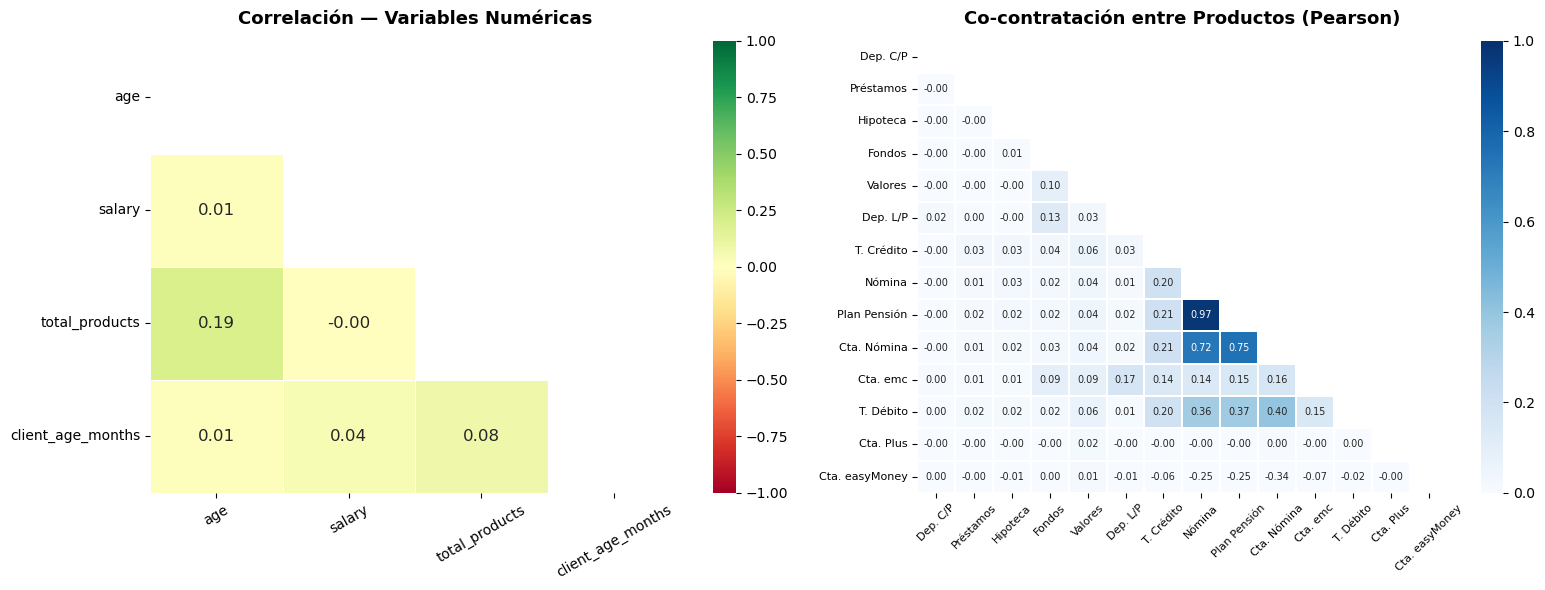

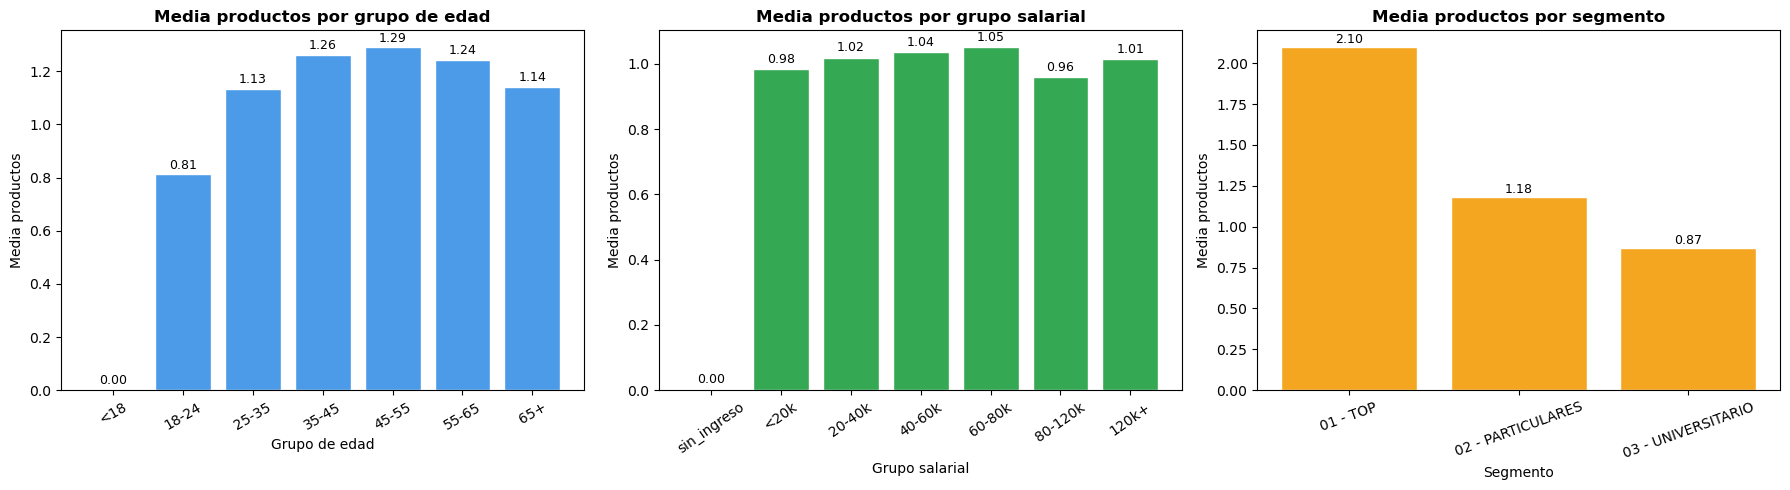

  CORRELACIONES CON total_products
  age                    r = +0.188  — ↑ positiva, moderada
  salary                 r = -0.004  — ↓ negativa, débil
  client_age_months      r = +0.079  — ↑ positiva, débil
  TOP 5 PARES PRODUCTOS MÁS CO-CONTRATADOS
  Plan Pensión       ↔  Nómina              r = 0.970
  Cta. Nómina        ↔  Plan Pensión        r = 0.746
  Cta. Nómina        ↔  Nómina              r = 0.724
  T. Débito          ↔  Cta. Nómina         r = 0.400
  T. Débito          ↔  Plan Pensión        r = 0.370


In [15]:
# ── Análisis de Correlaciones ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Usar snapshot de última partición (sin anomalías) para correlaciones
anomaly_flags = ["age_anomaly", "deceased_anomaly", "entry_date_anomaly"]
df_clean   = df[~df[anomaly_flags].any(axis=1)]
last_part  = df_clean["pk_partition"].max()
df_last    = df_clean[df_clean["pk_partition"] == last_part].copy()

print(f"Snapshot: {last_part.date()} — {len(df_last):,} registros")

# ── 1. Heatmap correlaciones numéricas ─────────────────────────────────────
numeric_cols = ["age", "salary", "total_products", "client_age_months"]
corr_num = df_last[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- subplot 1: numéricas ---
mask = np.triu(np.ones_like(corr_num, dtype=bool))
sns.heatmap(
    corr_num, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0],
    annot_kws={"size": 12}
)
axes[0].set_title("Correlación — Variables Numéricas", fontsize=13, fontweight="bold", pad=12)
axes[0].tick_params(axis="x", rotation=30)
axes[0].tick_params(axis="y", rotation=0)

# --- subplot 2: productos (binarios) ---
product_cols = ["short_term_deposit","loans","mortgage","funds","securities",
                "long_term_deposit","credit_card","payroll","pension_plan",
                "payroll_account","emc_account","debit_card","em_account_p","em_acount"]

label_map = {
    "em_acount":        "Cta. easyMoney",
    "em_account_p":     "Cta. Plus",
    "emc_account":      "Cta. emc",
    "payroll_account":  "Cta. Nómina",
    "payroll":          "Nómina",
    "debit_card":       "T. Débito",
    "credit_card":      "T. Crédito",
    "pension_plan":     "Plan Pensión",
    "funds":            "Fondos",
    "securities":       "Valores",
    "long_term_deposit":"Dep. L/P",
    "short_term_deposit":"Dep. C/P",
    "loans":            "Préstamos",
    "mortgage":         "Hipoteca"
}

corr_prod = df_last[product_cols].rename(columns=label_map).corr()
mask_prod = np.triu(np.ones_like(corr_prod, dtype=bool))
sns.heatmap(
    corr_prod, mask=mask_prod, annot=True, fmt=".2f",
    cmap="Blues", vmin=0, vmax=1,
    linewidths=0.3, ax=axes[1],
    annot_kws={"size": 7}
)
axes[1].set_title("Co-contratación entre Productos (Pearson)", fontsize=13, fontweight="bold", pad=12)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

# ── 2. total_products por grupo categórico ──────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

# Orden fijo para age_group
age_order = ["<18","18-24","25-35","35-45","45-55","55-65","65+"]
sal_order = ["sin_ingreso","<20k","20-40k","40-60k","60-80k","80-120k","120k+"]

# 2a. Media de productos por grupo de edad
age_prod = (
    df_last.groupby("age_group", observed=True)["total_products"]
    .mean().reindex(age_order)
)
axes2[0].bar(age_order, age_prod.values, color="#4C9BE8", edgecolor="white")
axes2[0].set_title("Media productos por grupo de edad", fontweight="bold")
axes2[0].set_xlabel("Grupo de edad")
axes2[0].set_ylabel("Media productos")
axes2[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(age_prod.values):
    if not np.isnan(v):
        axes2[0].text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# 2b. Media de productos por grupo de salario
sal_prod = (
    df_last.groupby("salary_group", observed=True)["total_products"]
    .mean().reindex(sal_order)
)
axes2[1].bar(sal_order, sal_prod.values, color="#34A853", edgecolor="white")
axes2[1].set_title("Media productos por grupo salarial", fontweight="bold")
axes2[1].set_xlabel("Grupo salarial")
axes2[1].set_ylabel("Media productos")
axes2[1].tick_params(axis="x", rotation=35)
for i, v in enumerate(sal_prod.values):
    if not np.isnan(v):
        axes2[1].text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# 2c. Media de productos por segmento
seg_prod = df_last.groupby("segment")["total_products"].mean().sort_values(ascending=False)
axes2[2].bar(seg_prod.index, seg_prod.values, color="#F4A620", edgecolor="white")
axes2[2].set_title("Media productos por segmento", fontweight="bold")
axes2[2].set_xlabel("Segmento")
axes2[2].set_ylabel("Media productos")
axes2[2].tick_params(axis="x", rotation=20)
for i, v in enumerate(seg_prod.values):
    axes2[2].text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# ── 3. Resumen numérico ─────────────────────────────────────────────────────
print("" + "="*60)
print("  CORRELACIONES CON total_products")
print("="*60)
correlaciones = df_last[["total_products","age","salary","client_age_months"]].corr()["total_products"].drop("total_products")
for var, val in correlaciones.items():
    direccion = "↑ positiva" if val > 0 else "↓ negativa"
    intensidad = "fuerte" if abs(val)>0.3 else "moderada" if abs(val)>0.1 else "débil"
    print(f"  {var:<22} r = {val:+.3f}  — {direccion}, {intensidad}")

print("" + "="*60)
print("  TOP 5 PARES PRODUCTOS MÁS CO-CONTRATADOS")
print("="*60)
corr_vals = corr_prod.where(np.tril(np.ones(corr_prod.shape), k=-1).astype(bool))
top_pairs = corr_vals.stack().sort_values(ascending=False).head(5)
for (p1, p2), val in top_pairs.items():
    print(f"  {p1:<18} ↔  {p2:<18}  r = {val:.3f}")

### Interpretación de correlaciones

#### 1. Variables numéricas vs. `total_products`

| Variable | r | Interpretación |
|---|---|---|
| `age` | +0.19 | Correlación **moderada positiva** — el grupo 45-55 tiene el mayor engagement (1.29 prod/cliente). Menores de 18 y 65+ tienen menor engagement (0.81 y 1.14). |
| `client_age_months` | +0.08 | Correlación **débil positiva** — la antigüedad importa pero menos de lo esperado. Los clientes no acumulan productos de forma progresiva con el tiempo. |
| `salary` | -0.00 | **Sin correlación** — el salary no predice el número de productos. Esto es en parte consecuencia de la imputación aplicada en el EDA, que redujo artificialmente la varianza entre grupos salariales. |

> ⚠️ **Nota metodológica sobre salary:** el gráfico por grupo salarial muestra valores casi idénticos (0.96–1.05 productos) en todos los tramos. Es un artefacto de la imputación por grupo de edad — no refleja necesariamente la realidad del negocio. Interpretar con cautela.

#### 2. Co-contratación entre productos

| Par | r | Interpretación |
|---|---|---|
| Plan Pensión ↔ Nómina | 0.97 | Correlación muy alta — probablemente se venden juntos como pack desde easyBanking. No indica causalidad independiente. |
| Cta. Nómina ↔ Plan Pensión | 0.75 | Mismo cluster "nómina" — clientes con nómina domiciliada tienden a contratar plan de pensiones. |
| Cta. Nómina ↔ Nómina | 0.72 | Productos complementarios del mismo pack — lógico. |
| T. Débito ↔ Cta. Nómina | 0.40 | El cliente con cuenta nómina tiende a sacar también tarjeta de débito. |
| Valores ↔ Dep. L/P | 0.13 | Perfil inversor incipiente — pequeña tendencia a combinar productos de inversión. |

> El cluster **Nómina / Plan Pensión / Cta. Nómina / T. Débito** forma un grupo cohesionado de alta co-contratación.
> Los productos de inversión (Fondos, Valores, Depósitos) muestran correlaciones muy bajas entre sí.
> Los productos de financiación (Préstamos, Hipoteca) tienen correlación casi nula con todo — son contratos puntuales y poco frecuentes.

#### 3. Segmento vs. productos

| Segmento | Media productos |
|---|---|
| 01 - TOP | **2.10** |
| 02 - PARTICULARES | 1.18 |
| 03 - UNIVERSITARIO | 0.87 |

> El segmento TOP tiene **2.4x más productos** que el universitario. La estrategia de cross-sell debería priorizar PARTICULARES como mayor impacto en volumen.

#### Implicaciones para Tarea 3 (Recomendación)

- **Edad** es la variable más predictiva para segmentar el targeting (grupo 35-55 tiene mayor engagement).
- El cluster **Nómina + Pensión + T. Débito** es un bundle natural que puede recomendarse como conjunto.
- **Salary** no debe usarse como feature de targeting directo dado el problema de imputación — puede usarse como señal secundaria en modelos, pero no como criterio principal.


In [16]:
# ── Guardar parquet final con todos los flags ──────────────────────────────
df.to_parquet('../../data/processed/master_df_flags.parquet', index=False)
print("\n" + "=" * 55)
print("  RESUMEN FINAL — TODOS LOS FLAGS DE CALIDAD")
print("=" * 55)

flags = ['age_anomaly', 'deceased_anomaly', 'entry_date_anomaly']
total = len(df)

for flag in flags:
    count = df[flag].sum()
    pct = count / total * 100
    clientes = df[df[flag]]['pk_cid'].nunique()
    print(f"\n  {flag}:")
    print(f"    Registros:        {count:>8,}  ({pct:.4f}%)")
    print(f"    Clientes únicos:  {clientes:>8,}")

# Registros con cualquier anomalía
any_anomaly = df[flags].any(axis=1)
print(f"\n  TOTAL con cualquier anomalía:")
print(f"    Registros:        {any_anomaly.sum():>8,}  ({any_anomaly.mean()*100:.4f}%)")
print(f"    Clientes únicos:  {df[any_anomaly]['pk_cid'].nunique():>8,}")

print(f"\n✓ Parquet guardado con {df.shape[1]} columnas")
print(f"✓ Nuevos flags: age_anomaly, deceased_anomaly, entry_date_anomaly")


  RESUMEN FINAL — TODOS LOS FLAGS DE CALIDAD

  age_anomaly:
    Registros:           4,806  (0.0806%)
    Clientes únicos:       504

  deceased_anomaly:
    Registros:             724  (0.0121%)
    Clientes únicos:       101

  entry_date_anomaly:
    Registros:          10,780  (0.1808%)
    Clientes únicos:    10,780

  TOTAL con cualquier anomalía:
    Registros:          16,272  (0.2729%)
    Clientes únicos:    11,360

✓ Parquet guardado con 37 columnas
✓ Nuevos flags: age_anomaly, deceased_anomaly, entry_date_anomaly


## Resumen de hallazgos por columna

| Columna | Estado | Hallazgo | Acción |
|---|---|---|---|
| `age` | ⚠️ | 4,432 registros con edad < 5 / 201 con edad > 100 / 187 menores con pension_plan | Flag `age_anomaly` |
| `active_customer` | ⚠️ | 59.7% registros inactivos — 70.2% de inactivos aún tienen productos | Documentado |
| `entry_channel` | ✅ | 3 canales = 80% tráfico. 41 canales raros pero impacto mínimo | Sin acción |
| `country_id` | ✅ | 99.96% España. 40 países restantes = 2,252 registros | Sin acción |
| `deceased` | ⚠️ | 718 fallecidos marcados como activos / 51 con nuevas contrataciones | Flag `deceased_anomaly` |
| `segment` | ✅ | 4 valores (3 + UNKNOWN). TOP tiene mayor engagement (94.4% activo) | Sin acción |
| `entry_date` | ⚠️ | 10,780 registros con entry_date 1-3 días posterior a pk_partition | Flag `entry_date_anomaly` |
| `salary` | ✅ | Imputación inteligente por grupo de edad aplicada en EDA | Sin acción |
| `gender` | ✅ | H / V / UNKNOWN — correcto | Sin acción |
| `region_code` | ✅ | 52 códigos + UNKNOWN — correcto | Sin acción |

---

## Flags de calidad añadidos

| Flag | Registros | % Total | Clientes únicos | Descripción |
|---|---|---|---|---|
| `age_anomaly` | 4,806 | 0.08% | 504 | Edad < 5, edad > 100, o menor de 18 con pension_plan |
| `deceased_anomaly` | 724 | 0.01% | 101 | Fallecido pero activo o con nuevas contrataciones |
| `entry_date_anomaly` | 10,780 | 0.18% | 10,780 | Entry_date 1-3 días posterior a pk_partition (retraso sistémico) |
| **TOTAL** | **16,272** | **0.27%** | **11,360** | Cualquier anomalía |

> **Conclusión:** La calidad general del dataset es muy buena — solo el 0.27%
> de los registros presentan anomalías. Todos los análisis posteriores
> (segmentación, recomendación, personalización) deben filtrar estos registros
> usando `df[~df[['age_anomaly','deceased_anomaly','entry_date_anomaly']].any(axis=1)]`

---

## Insight clave para el negocio

> ⚠️ **Solo el 40.3% de los clientes están activos** — el 59.7% son inactivos
> pero muchos aún mantienen productos contratados. Esto tiene implicaciones
> directas para la estrategia de Carol: el universo real de clientes
> accionables es significativamente menor de lo que los números brutos sugieren.
> Se recomienda segmentar siempre entre activos e inactivos en los análisis.